In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_performance_on_circles(
    performance_dict,
    category_labels=None,
    save_path="performance_circle_plot.pdf",
    title="Performance Across Categories at Different Radii",
    color_cycle=None,
    use_latex=True
):
    """
    Plot performance data on concentric circles (polar plot).

    Args:
        performance_dict (dict): Dictionary with keys as labels (e.g., model names)
                                 and values as lists or arrays of performance scores (one per angle).
        category_labels (list of str): Labels for each angular category (e.g., metrics).
        save_path (str): Path to save the figure as a PDF.
        title (str): Title of the plot (LaTeX accepted).
        color_cycle (list of str): List of matplotlib color codes (optional).
        use_latex (bool): Whether to use LaTeX fonts.
    """
    if use_latex:
        plt.rcParams.update({
            "text.usetex": True,
            "font.family": "serif",
            "font.serif": ["Times"],
            "axes.labelsize": 12,
            "font.size": 12,
            "legend.fontsize": 10,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
        })

    n_categories = len(next(iter(performance_dict.values())))
    angles = np.linspace(0, 2 * np.pi, n_categories, endpoint=False)
    if category_labels is None:
        category_labels = [f"$C_{{{i+1}}}$" for i in range(n_categories)]

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))

    color_cycle = color_cycle or plt.rcParams['axes.prop_cycle'].by_key()['color']
    for i, (label, values) in enumerate(performance_dict.items()):
        values = np.asarray(values)
        theta = np.concatenate([angles, [angles[0]]])
        r = np.concatenate([values, [values[0]]])  # close the loop

        ax.plot(theta, r, label=label, color=color_cycle[i % len(color_cycle)])
        ax.fill(theta, r, alpha=0.2, color=color_cycle[i % len(color_cycle)])

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(0)
    ax.set_xticks(angles)
    ax.set_xticklabels(category_labels, fontsize=12)
    ax.set_yticklabels([])

    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    ax.set_title(rf"\textbf{{{title}}}", fontsize=14, y=1.08)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()


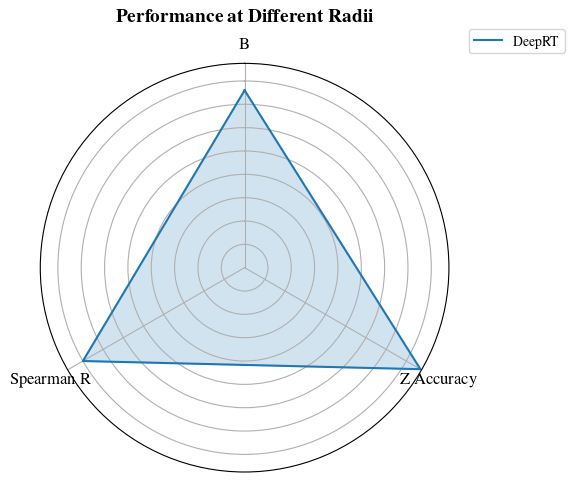

In [4]:
# Example performance data
performance = {
    "DeepRT": [76, 87, 0.8*100],
}
category_labels = ["B% Accuracy", "Z Accuracy", "Spearman R"]

plot_performance_on_circles(
    performance_dict=performance,
    category_labels=category_labels,
    save_path="circle_plot.pdf",
    title="Performance at Different Radii"
)
